# BEE 4310/6310: Environmental Statistics and Learning  <br> Assignment #5 (10 pts)

**Include responses to everything below in bold (including plots), and make sure your final assignment is well organized in a single markdown PDF submitted to Canvas. This makes it easier to grade (and easier to give partial credit).**

**Remember to include an acknowledgement at the bottom of this assignment if generative AI was used for coding support, including a list of the problems for which it was used.**

<img src="LearningOutcomes_5.png" width="1000"/>

**Techniques and Topics:** 
- Kernel-weighted averages
- Local linear regression
- Bandwidth selection
- Classification and regression trees
- Bagging
- Boosting
- Cross validation
- Random forest

**Packages and functions covered in Data Camp exercises (note: many will not be needed in the problems below)** 

| numpy as np       | Matplotlib.pyplot as plt  | pandas as pd  | scipy.stats | seaborn as sns | statsmodels.formula.api | statsmodels.api as sm |
| -----------       | ------------------------  | ------------  | ----------- | -------------- | ----------------------- | --------------------- |  
|np.array           | plt.plot                  | pd.DataFrame  | uniform.cdf | sns.scatterplot| ols                     | sm.qqplot             |
|np.mean            | plt.show                  | pd.read_csv   | uniform.rvs | sns.lmplot     | ols.fit                 | sm.families.Gaussian  |
|np.median          | plt.xscale                | pd.get_dummies| uniform.ppf | sns.regplot    | ols.params              | sm.families.Binomial  |
|np.var             | plt.yscale                | pd.concat     | binom.cdf   | sns.displot    | ols.predict             | sm.families.Poisson   |
|np.std             | plt.scatter               | pd.crosstab   | binom.rvs   | sns.residplot  | ols.fittedvalues        |
|np.quantile        | plt.hist                  | df.iloc       | binom.ppf   |                | ols.resid
|np.random.rand     | plt.clf                   | df.loc        | norm.cdf    |                | ols.rsquared
|np.random.randint  | plt.xlabel                | df.apply      | norm.rvs    |                | ols.mse_resid
|np.random.seed     | plt.tlabel                | df.iterrows   | norm.ppf    |                | ols.summary
|np.logical_or      | plt.title                 | df.sample     | poisson.cdf |                | ols.get_influence().resid_studentized_internal
|np.logical_and     | plt.xticks                | df.assign     | poisson.rvs |                | ols.get_influence().summary_frame()
|np.nditer          | plt.yticks                | df.drop       | poisson.pmf |                | logit
|np.transpose       | plt.text                  | df.dropna     |             |                | logt.pred_table
|np.arange          | plt.grid                  | df.isnull     |             |                | glm
|np.append          | plt.figure                | df.describe   |             |                | glm.fit
|np.where           | plt.axis                  | series.corr   |             |                | glm.params
|                   | plt.axhline               |               |             |                | glm.predict
|                   | plt.axvline               |               |             |                | glm.fittedvalues
|                   | plt.bar                   |               |             |                | glm.cov_params
|                   |                           |               |             |                | glm.conf_int


| sklearn.linear_model           | sklearn.model_selection| sklearn.preprocessing        | sklearn.neighbors             | sklearn.metrics        |
| ------------------------------ | -----------------------| ---------------------        | ----------------------------- | ---------------------- |
| LinearRegression               | train_test_split       | StandardScaler               | KNeighborsClassifier          | mean_squared_error     | 
| LinearRegression.fit           | cross_val_score        | StandardScaler.fit_transform | KNeighborsClassifier.fit      | classification_reports |
| LinearRegression.predict       | KFold                  | StandardScaler.transform     | KNeighborsClassifier.predict  | confusion_matrix       | 
| LinearRegression.score         | GridSearchCV           |                              | KNeighborsClassifier.score    | roc_curve              | 
Ridge                            | RandomizedSearchCV     |                              |                               | roc_auc_score          | 
Ridge.fit                        |                        |                              |                               | accuracy_score         |
Ridge.predict                    |
Ridge.score                      |
Lasso                            |
Lasso.fit                        |
Lasso.predict                    |
Lass.score                       |
LogisticRegression               | 
LogisticRegression.fit           | 
LogisticRegression.predict       | 
LogisticRegression.predict_proba | 


| sklearn.impute                | sklearn.pipeline  | sklearn.tree                    | sklearn.ensemble                    |
| --------------                | ----------------- | ------------------              | ----------------                    |
| SimpleImputer                 | Pipeline          | DecisionTreeClassifier          | VotingClassifier                    |
| SimpleImputer.fit_transform   | Pipeline.fit      | DecisionTreeClassifier.fit      | VotingClassifier.fit                |
| SimpleImputer.transform       | Pipeline.predict  | DecisionTreeClassifier.predict  | VotingClassifier.predict            |
|                               | Pipepline.score   | DecisionTreeRegressor           | BaggingClassifier                   |
|                               |                   | DecisionTreeRegressor.fit       | BaggingClassifier.fit               |
|                               |                   | DecisionTreeRegressor.predict   | BaggingClassifier.predict           |
|                               |                   |                                 | BaggingRegressor                    |
|                               |                   |                                 | BaggingRegressor.fit                |
|                               |                   |                                 | BaggingRegressor.predict            |
|                               |                   |                                 | RandomForestClassifier              |
|                               |                   |                                 | RandomForestClassifier.fit          |
|                               |                   |                                 | RandomForestClassifier.predict      |
|                               |                   |                                 | RandomForestClassifier.feature_importances_  |
|                               |                   |                                 | RandomForestRegressor                        |
|                               |                   |                                 | RandomForestRegressor.fit                    |
|                               |                   |                                 | RandomForestRegressor.predict                |
|                               |                   |                                 | AdaBoostClassifier                           |
|                               |                   |                                 | AdaBoostClassifier.fit                       |
|                               |                   |                                 | AdaBoostClassifier.predict                   |
|                               |                   |                                 | GradientBoostingRegressor                    |
|                               |                   |                                 | GradientBoostingRegressor.fit                |
|                               |                   |                                 | GradientBoostingRegressor.predict            |


<img align="right" src="Patuxent_River_Map.png" width="600"/>

The majority of this assignment will use kernel-weighted averages, local linear regession, and regession trees to examine the total phosphorus (TP) concentration in the Patuxent River near Bowie Maryland, which discharges into the Chessapeake Bay (shown to the right). The Chessapeake Bay has for decades suffered from low oxygen levels because excess nutrients (i.e., nitrogen and phosphorus) are discharged into the bay from rivers draining the surrounding Mid-Atlantic states. These nutrients fuel algae growth (eutrophication), which ultimately leads to severe water quality degradation. 

The watershed draining into the Patuxent River contains a large and growing suburban population, which produces sewage with high nutrient content that gets discharged into the river and then the bay. The watershed also contains a substantial amount of farmland, which also produces nutrient-rich runoff. 

In the late 1970's, advanced sewage treatment plants were installed to reduce nutrient concentrations of waterwater discharges. There were also national limits placed on phosphate detergents, further restricting total phosphorus discharges from factories. Together, these policies reduced TP concentrations in the river over time. 

However, questions remain about the mechanisms by which river discharge influences variations in TP concentrations. Under one mechanism (called 'dillution'), TP concentrations fall when river flows rise, because the mass of nutrient pollution (e.g., from sewage plants) is dilluted into a larger amount of water. Under another mechanism (called 'entrainment'), TP concentrations rise when river flows rise, because those higher flows are more effective at washing nutrient pollution (e.g., manure and fertilizer on farms) from the land surface into the river. We are interested in understanding which mechanism is dominant in the Patuxent River, and whether the dominant mechanism has changed over time in response to policies meant to reduce phosphorus pollution from sewage plants and detergent factories. 

In addition, there are often seasonal patterns in nutrient runoff that repeat every year based on cyclic processes in the watershed. For instance, farmers tend to spread manure on their fields around the same time each year, which is followed by a rise in nutrient runoff. However, as processes change in the watershed over time (e.g., shifts in the dominance of dillution vs. entrainment), so too can the seasonal patterns of nutrient concentrations (i.e., the timing and magnitude of seasonal peaks and troughs). We are also interested in exploring these TP dynamics in the Patuxent River. 

Finally, the very end of this assignment will revist the ebird dataset from Assignment 4, exploring how random forests can be used to improve predictive performance. 

1. Import the following packages: numpy, pandas, matplotlib.pyplot. Also import statsmodels.api as sm. Note: you will need to import other packages further down in the assignment. 

    Download the Patuxent_River.csv file from Canvas under Assignment 5 and load in this data as a Pandas dataframe called 'Patuxent'. This file contains:
    - The date of daily observations 
    - The concentration of total phosphorus (mg/L), hereafter referred to as TP
    - The flow in the river (in cubic feet per second, or cfs)

    Note: The dates run from 1978 to 2023, but they are measured with irregular frequency throughout this time frame. That is, there is not a measurement on every day. In some years, there are measurements approximately once per month, and in other periods, 1-2 per week. 

    Also note: In the code block below, I have provided some started code to create a new column in the dataframe Patuxent called 'decimal_date', which equals the year plus the fraction of the year that has passed up to that given day (i.e., the day of the year divided by 366). For example, the date January 30, 2000 will be coded as 2000.082 = 2000+30/366. This 'decimal_date' column will provide a continuous time variable against which to examine time trends. 
  

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

Patuxent = pd.read_csv('Patuxent_River.csv')

#<create decimal_date column>
Patuxent['decimal_date'] = pd.DatetimeIndex(Patuxent.date).year + pd.DatetimeIndex(Patuxent.date).dayofyear/366

print(Patuxent.head())

         date  Flow_cfs  TP_mg_L  decimal_date
0  1978-01-30    1060.0     0.12   1978.081967
1  1978-03-14     924.0     0.18   1978.199454
2  1978-04-11     314.0     0.37   1978.275956
3  1978-05-10     997.0     0.12   1978.355191
4  1978-05-15    1580.0     0.10   1978.368852


2. **(1 pt) Create histograms of both flow and TP in a 2-panel plot. Comment on the shape of the distributions of these variables.** 

    For both flow and TP, place log-transformed versions of these variables into new columns in the Patuxent dataframe called 'log_flow' and 'log_TP'. We will reference these columns in all of the problems below. 

    **Create histograms of log_flow and log_TP in another 2-panel plot, and comment on how the shape of the distribution of these variables differs from the untransformed versions of the variables.**

    **Plot both log_flow and log_TP against the 'decimal_date' column. Also plot log_flow and log_TP against each other. Briefly comment on the time trends in log_flow and log_TP, and the shape of the relationship between log_flow and log_TP.**

    Do not forget to label all axes for each plot. 

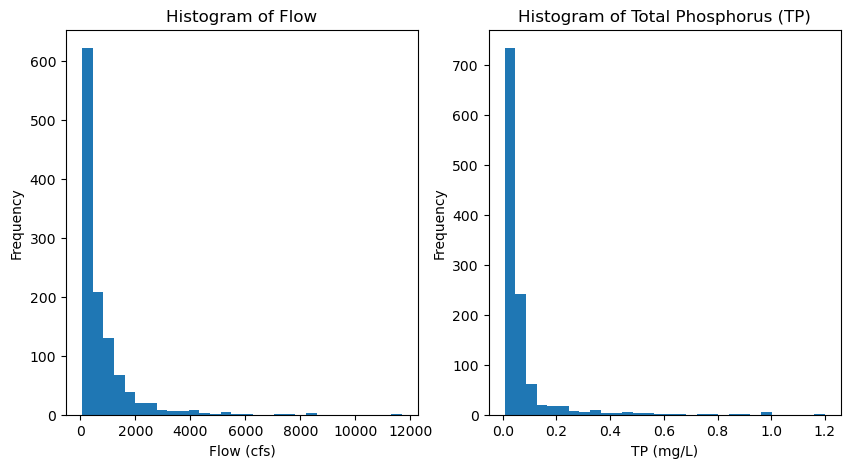

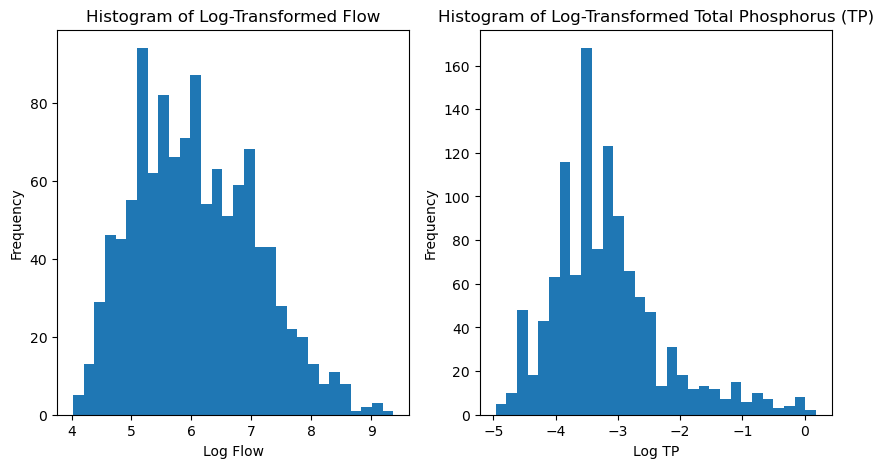

In [131]:
# Create histograms of flow and TP in 2-panel plot
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.hist(Patuxent['Flow_cfs'], bins=30)
plt.title('Histogram of Flow')
plt.xlabel('Flow (cfs)')
plt.ylabel('Frequency') 

plt.subplot(1, 2, 2)
plt.hist(Patuxent['TP_mg_L'], bins=30)
plt.title('Histogram of Total Phosphorus (TP)')
plt.xlabel('TP (mg/L)')
plt.ylabel('Frequency')

# Define the log-transformed versions of flow and TP
Patuxent['log_Flow'] = np.log(Patuxent['Flow_cfs'])
Patuxent['log_TP'] = np.log(Patuxent['TP_mg_L'])

#Create histograms of log-transformed flow and TP in 2-panel plot
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.hist(Patuxent['log_Flow'], bins=30)
plt.title('Histogram of Log-Transformed Flow')
plt.xlabel('Log Flow')
plt.ylabel('Frequency') 

plt.subplot(1, 2, 2)
plt.hist(Patuxent['log_TP'], bins=30)
plt.title('Histogram of Log-Transformed Total Phosphorus (TP)')
plt.xlabel('Log TP')
plt.ylabel('Frequency')

plt.show()

The nontransformed distributions are right-skewed, whilst the log-transformed approach a more normal distribution.

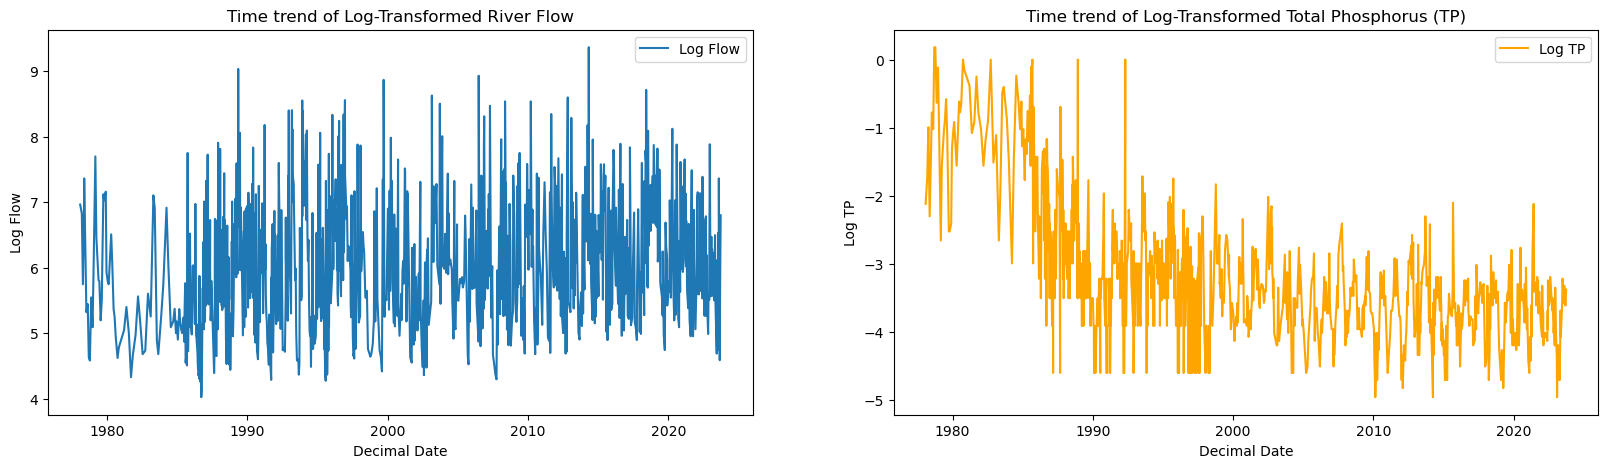

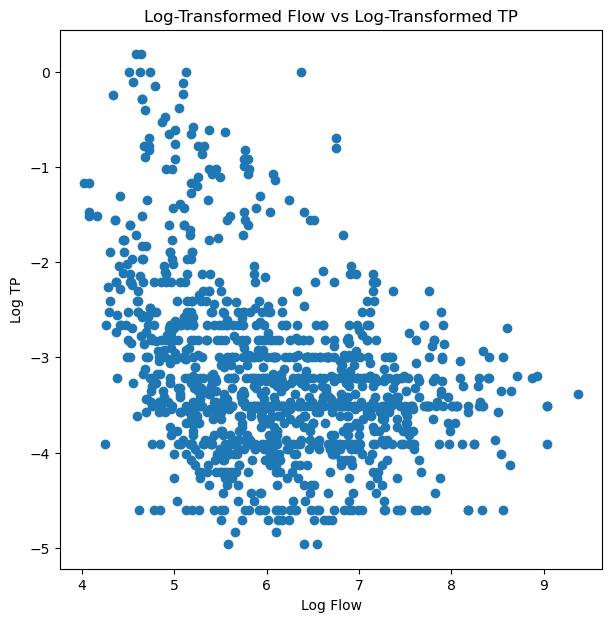

In [132]:
# Plot log_Flow & log_TP against decimal_date column, to view time trends
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(Patuxent['decimal_date'], Patuxent['log_Flow'])
plt.title('Time trend of Log-Transformed River Flow')
plt.xlabel('Decimal Date')
plt.ylabel('Log Flow')
plt.legend(['Log Flow'])

plt.subplot(1, 2, 2)
plt.plot(Patuxent['decimal_date'], Patuxent['log_TP'], color='orange')
plt.title('Time trend of Log-Transformed Total Phosphorus (TP)')
plt.xlabel('Decimal Date')
plt.ylabel('Log TP')
plt.legend(['Log TP'])

plt.show()

# Plot log Flow and log TP against each other
plt.figure(figsize=(7, 7))
plt.scatter(Patuxent['log_Flow'], Patuxent['log_TP'])
plt.title('Log-Transformed Flow vs Log-Transformed TP')
plt.xlabel('Log Flow')
plt.ylabel('Log TP')
plt.show()

By looking at the time trends of log Flow and log TP, they both have a seasonaility component as the values keep on bouncing up and down at a consistent frequency within a year. Further, there was a clear decrease in Phosphorus concentrations around 1990, which is linked to the water policy against point-pollution. After that, the concentration looks fairly constant.

Further, the scatterplot between log TP and log Flow showcases a negative relationship, thus as Flow increases, TP decreases.

3. **(1 pt)** In this problem, you will use a kernel to develop a scatterplot smoothing of the log-TP data against time. 

    Create your own function, called gaussian_kernel, that takes as input a specific value x0, a vector of values x, and a bandwidth, and returns the Gaussian kernel for the values in x based on their distance to x0 and the bandwidth.  

    Loop through all rows in the dataframe Patuxent, and for each iteration i in the loop, calculate the kernel-weighted average of the ith observation of log-TP, based on kernel weights derived from the 'decimal_date' column (i.e., x0 in this case equals the ith value of decimal_date, and x equals all values in the 'decimal_date' column). Calculate the kernel-weighted average using two separate bandwidths for the Gaussian kernel: 1 year and 5 years. 
    
    **Create a scatter plot of log-TP vs. decimal_date. Be sure to label all axes. Add to this plot two lines (colored orange and purple) for the two kernel-weighted averages associated with the two bandwidths. Add a legend for these two lines. Briefly comment on one similarity and one difference between the two kernel-weighted averages.**

In [133]:
#Create Kernel function
def gaussian_kernel(x0, x, bandwidth):
    #Define t
    t = (x0 - x) / bandwidth

    #Create Gaussian Kernel function
    Dt = 1/np.sqrt(2 * np.pi) * np.exp(-0.5 * (t**2))
    
    return Dt

In [134]:
weighted_avg_1_list = []
weighted_avg_5_list = []

#Loop through DataFrame
for i, row in Patuxent.iterrows():
    x0 = row['decimal_date']
    x = Patuxent['decimal_date'].values
    #Define bandwidths
    bandwidth_1 = 1
    bandwidth_5 = 5
    #Define Kernel-Weights
    weights_1 = gaussian_kernel(x0, x, bandwidth_1)
    weights_5 = gaussian_kernel(x0, x, bandwidth_5)
    #Kernel weighted-average
    weighted_avg_1 = np.sum(weights_1 * Patuxent['log_TP']) / np.sum(weights_1)
    weighted_avg_5 = np.sum(weights_5 * Patuxent['log_TP']) / np.sum(weights_5)
    #Store weighted-averages in new columns
    weighted_avg_1_list.append(weighted_avg_1)
    weighted_avg_5_list.append(weighted_avg_5)

print(weighted_avg_1_list)
print(weighted_avg_5_list)

[np.float64(-1.2334883091685418), np.float64(-1.226508645179048), np.float64(-1.2225297277208036), np.float64(-1.2188636411352134), np.float64(-1.2182767967892936), np.float64(-1.2124596846727393), np.float64(-1.2095957551913727), np.float64(-1.207618361342386), np.float64(-1.205858157840488), np.float64(-1.2038632307222064), np.float64(-1.2019622052714005), np.float64(-1.2003459042627866), np.float64(-1.1975948752203034), np.float64(-1.1956772098847086), np.float64(-1.1903011568570039), np.float64(-1.1878009349425167), np.float64(-1.183028666757568), np.float64(-1.1781646680999407), np.float64(-1.1696754727560148), np.float64(-1.1647438270899797), np.float64(-1.1537281411796738), np.float64(-1.1476765460304004), np.float64(-1.138112703271122), np.float64(-1.1280112372108444), np.float64(-1.110515690199232), np.float64(-1.101527520114947), np.float64(-1.089442466298729), np.float64(-1.072560298911374), np.float64(-1.059960516334316), np.float64(-1.0451716820842785), np.float64(-1.02194

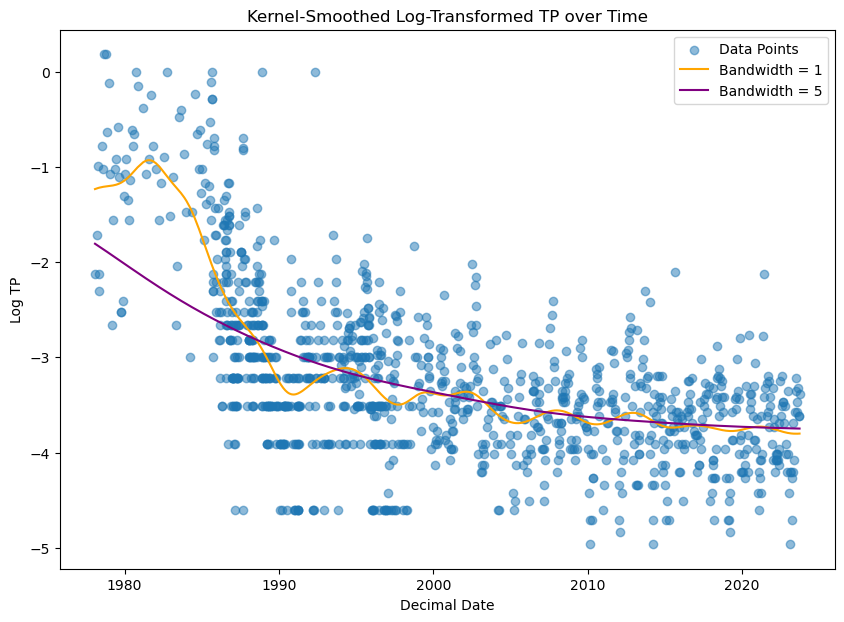

In [135]:
#Create Scatterplot with Kernel-Smoothed lines
plt.figure(figsize=(10, 7))
plt.scatter(Patuxent['decimal_date'], Patuxent['log_TP'], alpha=0.5, label='Data Points')
plt.plot(Patuxent['decimal_date'], weighted_avg_1_list, color='orange', label='Bandwidth = 1')
plt.plot(Patuxent['decimal_date'], weighted_avg_5_list, color='purple', label='Bandwidth = 5')
plt.title('Kernel-Smoothed Log-Transformed TP over Time')
plt.xlabel('Decimal Date')
plt.ylabel('Log TP')
plt.legend()
plt.show()

The Kernell weighted averages smooth the data by averaging nearby points, with closer points given more weight. A smaller bandwidth (e.g., 1) results in a curve that closely follows the data, capturing more local fluctuations (overfitting more), while a larger bandwidth (e.g., 5) produces a smoother curve that highlights broader trends by averaging over a wider range of data points.

4. **(1 pt)** Ultimately we want to develop a local linear model that helps us understand how log-TP varies not only with time, but also with flow and season, and also how these relationships vary in the dataset. The final regression model of interest is given as: 

            log-TP = B0 + B1*decimal_date + B2*log-flow + B3*cos(2*pi*decimal_date) + B4*sin(2*pi*decimal_date)

    We will develop the building blocks of this model and explore its outcomes in this problem and next three (#5-#7). Here we focus on the last two terms of this regression, cos(2 * pi * decimal_date) and sin(2 * pi * decimal_date), which provide a simple way to incorporate a seasonal signal into the regression. 

    Add two new columns to the Patuxent dataframe, called 'cost' and 'sint', which equal the cosine and sine of 2 * pi * decimal_date, respectively.

    Then, create three variables (seasonal_signal1, seasonal_signal2, seasonal_signal3) equal to B3*cos(2 * pi * decimal_date) + B4*sin(2 * pi * decimal_date), with the following values of B3 and B4:
    - seasaonal_signal1: B3=.5, B4=.5
    - seasaonal_signal2: B3=1.5, B4=.15
    - seasaonal_signal3: B3=-1.05, B4=1.95

    **On a single figure, plot each of these three variables against decimal_date for the last 50 values in each vector. Be sure to label all axes and add a legend.**

    Note the very different seasonal signals that are possible using this approach, in terms of both the timing and magnitude of seasonal peaks and valleys.  

        

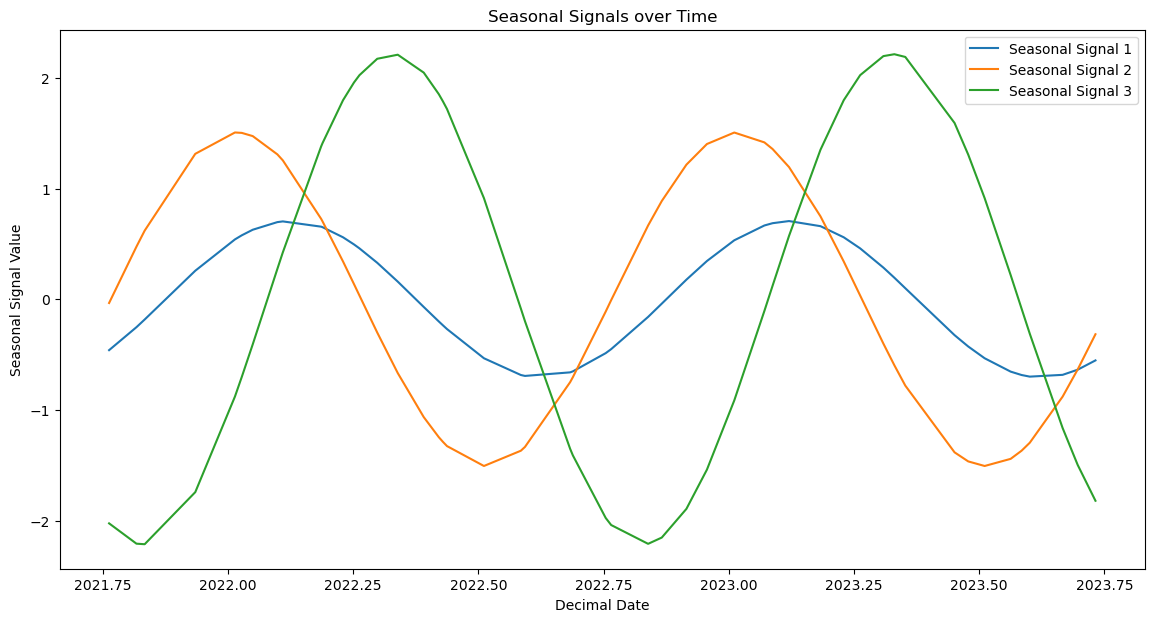

In [136]:
#Add two new columns to DataFrame
Patuxent['cost'] = np.cos(2*(np.pi*Patuxent['decimal_date']))
Patuxent['sint'] = np.sin(2*(np.pi*Patuxent['decimal_date']))

#Create three variables for regression
seasonal_signal1 = Patuxent['cost']*0.5 + Patuxent['sint']*0.5
seasonal_signal2 = Patuxent['cost']*1.5 + Patuxent['sint']*0.15
seasonal_signal3 = Patuxent['cost']*-1.05 + Patuxent['sint']*1.95

#Plot seasonal signals
plt.figure(figsize=(14, 7))
plt.plot(Patuxent['decimal_date'][-50:], seasonal_signal1[-50:], label='Seasonal Signal 1')
plt.plot(Patuxent['decimal_date'][-50:], seasonal_signal2[-50:], label='Seasonal Signal 2')
plt.plot(Patuxent['decimal_date'][-50:], seasonal_signal3[-50:], label='Seasonal Signal 3')
plt.title('Seasonal Signals over Time')
plt.xlabel('Decimal Date')
plt.ylabel('Seasonal Signal Value')
plt.legend()
plt.show()

5. **(1 pt)** In the local regression model: 

            log-TP = B0 + B1*decimal_date + B2*log-flow + B3*cos(2*pi*decimal_date) + B4*sin(2*pi*decimal_date)

    the coefficients B0, B1, B2, B3, B4 will be re-estimated for every observation x0 in the dataset, based on a kernel weighting that depends on the distance between x0 and all other observations in the data. 

    In this problem we will develop these kernel weights for the specific observation on January 5, 2000, i.e., when Patuxent['decimal_date'] equals (2000 + 5/366). 
    
    Create your own function, called gaussian_kernel_mv (a multivariate Gaussian kernel), that takes as input a vector x0, an array of values x, and a vector of bandwidths, and returns a product kernel (the product of individual Gaussian kernels for each predictor). Use this function to estimate the kernel weights for all observations in the data, using the following values for each argument:
    - set x0 equal to a 1D array with four elements equal to the values of decimal_date, log_flow, cost, and sint on January 5, 2000
    - set x equal to an nX4 array (matrix) that contains all *n* values of decimal_date, log_flow, cost, and sint across the entire record
    - set bandwidth equal to a 1D array with four elements, 5, 2, .5, and .5. These will be the bandwidths we use associated with decimal_date, log_flow, cost, and sint.
        - these bandwidth values were selected based on the range of each variable, and a desire to identify slowly varying (i.e., smooth) changes in the coefficients B1, B2, B3, B4 across the dataset.
    
    To create kernel weights, remember to divide the resulting kernel values by the sum of all kernel values, which will result in weights that sum to unity. 

     **Plot the resulting kernel weights against decimal_date. Be sure to label all axes. Comment on two features you notice about how these weights vary over the observations across time.** 

In [137]:
#Create Kernel function
from curses import raw


def gaussian_kernel_mv(x0, X, bandwidths):
    #Define t
    t = (X - x0) / bandwidths

    #Create Gaussian Kernel for each predictor
    K = 1/np.sqrt(2 * np.pi) * np.exp(-0.5 * (t**2))
    
    #Combine predictor kernels
    raw_W = np.prod(K, axis=1)
    weights = raw_W / np.sum(raw_W)
    return weights

In [138]:
# Define target date
target_date = 2000 + 5/366
row0 = Patuxent.loc[Patuxent['decimal_date'] == target_date].iloc[0]

x0 = np.array([
    row0['decimal_date'],
    row0['log_Flow'],
    row0['cost'],
    row0['sint']
])

X = Patuxent[['decimal_date', 'log_Flow', 'cost', 'sint']].values

bandwidths = np.array([5, 2, 0.5, 0.5])

weights = gaussian_kernel_mv(x0, X, bandwidths)


Text(0, 0.5, 'kernel weight')

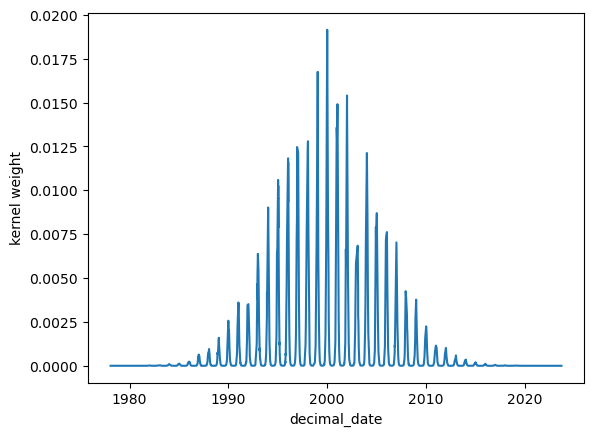

In [139]:
plt.plot(Patuxent['decimal_date'].values, weights)
plt.xlabel('decimal_date')
plt.ylabel('kernel weight')

The plot shows that kernel weights are highest near the central years and decrease smoothly as observations move farther away in time. This means that data points closest to the target date have the most influence, while earlier and later years contribute very little. The pattern is also symmetric, with weights tapering off evenly on both sides, reflecting how the kernel gives equal importance to observations the same distance from the center.

6. **(1 pt)** In this problem we will estimate the local regression model: 

            log-TP = B0 + B1*decimal_date + B2*log-flow + B3*cos(2*pi*decimal_date) + B4*sin(2*pi*decimal_date)

    where the coefficients B0, B1, B2, B3, B4 are re-estimated for every observation in the dataset. 

    In statsmodels, you can use sm.nonparametric.KernelReg to fit a local linear regression (i.e., kernel regression). I have provided some starter code in the code block below to fit this model. The object local_reg will have two elements, the first equaling the fitted values of the regression. The second element will contain an nX4 array of marginal effects, i.e., the estimated values of B1, B2, B3, B4 for each of the *n* observations in the data. 

    Based on the documentation for sm.nonparametric.KernelReg, fill in the required arguments to fit the local regession. Note that:
    - We will use bandwidth values of 5, 2, .5, and .5 for decimal_date, log_flow, cost, and sint, respectively. This will lead to a relatively smooth model to support interpretation. 
    - Set var_type = 'cccc', which means that all four predictors are continuous.
    - Set reg_type = 'll', because we want to fit a local linear regression model.
    - Use a Gaussian kernel.

    **In a 3-panel figure (with labeled axes), plot:**
    - **the observed log-TP values against the fitted values**
    - **the estimates of B1 (first column of marginal_effects) against decimal_date**
    - **the estimates of B2 (second column of marginal_effects) against decimal_date**
 
    **Briefly summarize the effects of both decimal_date and log_flow on log-TP early in the record, and how these effects change later in the record. For log_flow in particular, what does this tell us about the dominant mechanisms governing how river flow influences TP concentrations (dilution vs. entrainment), and how these mechanisms have changed over time?**



In [140]:
#<starter code for kernel regression>
local_reg = sm.nonparametric.KernelReg(endog = Patuxent['log_TP'], exog = X,var_type='cccc', reg_type='ll', bw = bandwidths).fit()
fitted_values = local_reg[0]
marginal_effects = local_reg[1]



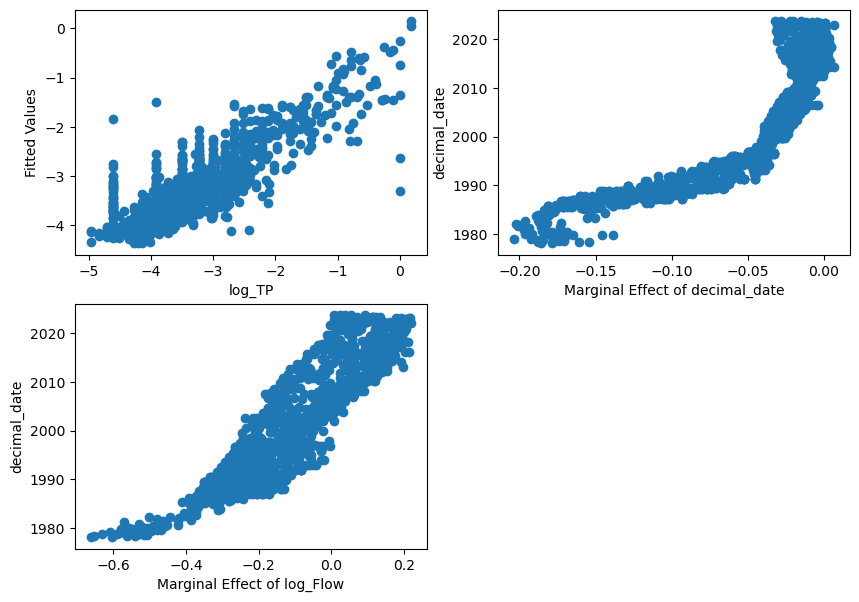

In [141]:
plt.figure(figsize=(10, 7))
plt.subplot(2, 2, 1)
plt.scatter(Patuxent['log_TP'], fitted_values)
plt.xlabel('log_TP')
plt.ylabel('Fitted Values')

plt.subplot(2, 2, 2)
plt.scatter(marginal_effects[:, 0], Patuxent['decimal_date'])
plt.xlabel('Marginal Effect of decimal_date')
plt.ylabel('decimal_date')

plt.subplot(2, 2, 3)
plt.scatter(marginal_effects[:, 1], Patuxent['decimal_date'])
plt.xlabel('Marginal Effect of log_Flow')
plt.ylabel('decimal_date')
plt.show()


Early in the record, the marginal effect of decimal_date is more negative, meaning log-TP was generally decreasing over time. Later in the record, this effect becomes close to zero, suggesting that long-term declines have flattened out. For log_flow, the early effect is strongly negative, which is consistent with dilution where higher flows reduce TP concentrations. Later in the record, the effect becomes weaker and even slightly positive, suggesting that high flows are now more associated with entrainment, meaning they bring more TP into the river. This indicates a shift from dilution being dominant early on to entrainment becoming more influential in recent years.

7. **(1 pt) Using the fitted local linear regression from problem #6, create a 2-panel figure that plots the seasonal signal against decimal date for:**
 - **all observations prior to 1980.00**
 - **all observations on or after 2022.00**

    Here, the seasonal signal can be calculated as B3[t]*cost[t] + B4[t]*sint[t], similar to problem #4 above. 

    Be sure to label all axes, and set the same y axis range for both panels.

    **Briefly comment on one major difference in the seasonal signal in the data from earlier in the record compared to later in the record.**

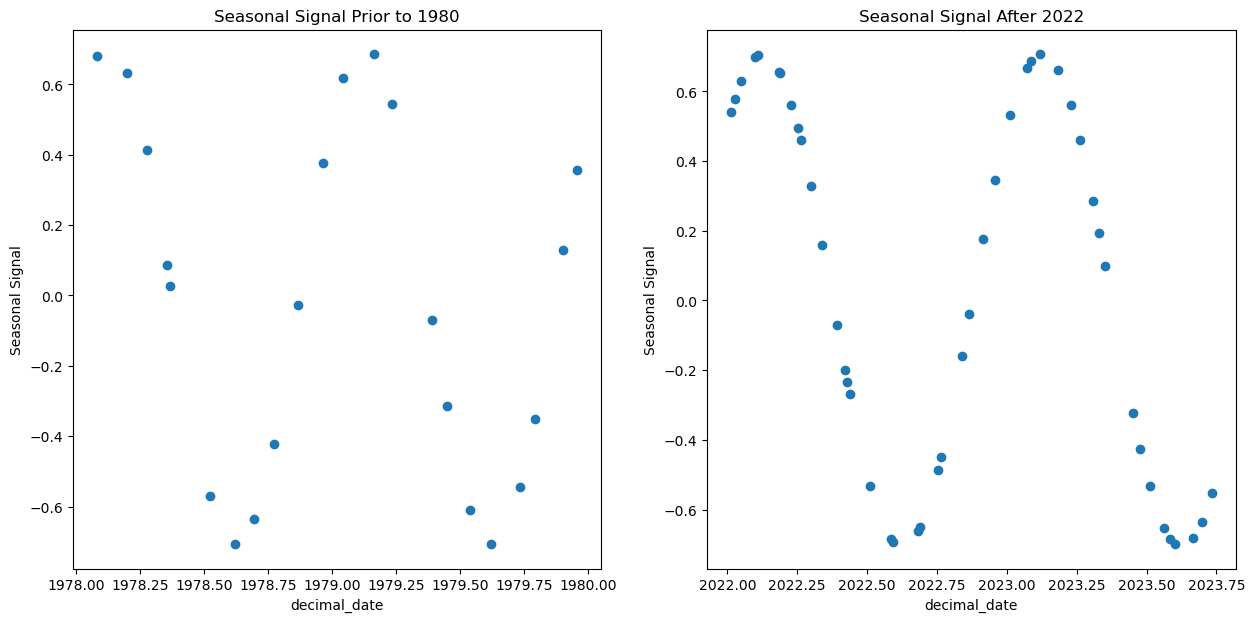

In [142]:
#Define seasonal components
seasonal_signal_prior = Patuxent[(Patuxent['decimal_date'] < 1980)]['cost']*0.5 + Patuxent[(Patuxent['decimal_date'] < 1980)]['sint']*0.5
seasonal_signal_after = Patuxent[(Patuxent['decimal_date'] >= 2022)]['cost']*0.5 + Patuxent[(Patuxent['decimal_date'] >= 2022)]['sint']*0.5

plt.figure(figsize=(15, 7))
plt.subplot (1, 2, 1)
plt.scatter(Patuxent[(Patuxent['decimal_date'] < 1980)]['decimal_date'], seasonal_signal_prior)
plt.title('Seasonal Signal Prior to 1980')
plt.xlabel('decimal_date')
plt.ylabel('Seasonal Signal')

plt.subplot (1, 2, 2)
plt.scatter(Patuxent[(Patuxent['decimal_date'] >= 2022)]['decimal_date'], seasonal_signal_after)
plt.title('Seasonal Signal After 2022')
plt.xlabel('decimal_date')
plt.ylabel('Seasonal Signal')
plt.show()

A clear difference is that the seasonal signal later in the record shows a much stronger and more consistent pattern, with peaks and troughs that are sharper and more regular. In contrast, the early record looks noisier and less organized, with a weaker or less defined seasonal cycle. This suggests that seasonality in TP has become more pronounced in recent years.

8. **(1 pt)** We will now change techniques and fit a regression tree to the log-TP data instead of a local linear model. Fit a decision tree using all the data in the Patuxent dataframe, the same predictors as before (decimal_date, log_flow, cost, sint), a maximum depth of 3, and random_state=1. 

    **Once the model is trained, use the function plot_tree (imported from sklearn.tree) to visualize the regression tree. Be sure to label the nodes in the tree using the feature_names argument, so that the tree is interpretable. Note that the left branch below each node in the tree is always the 'true' outcome of that node.**

    **Report one similarity and one difference between the logic that underlies the regression tree and the insights you developed based on the local linear model from problems #6 and #7? That is, what is one predictor/predictand relationship that is similar between the two approaches, and what is one relationship that is different (or easier to identify with one model over the other)?** 



[Text(0.5, 0.875, 'decimal_date <= 1986.835\nsquared_error = 0.812\nsamples = 1153\nvalue = -3.192'),
 Text(0.25, 0.625, 'decimal_date <= 1985.714\nsquared_error = 0.738\nsamples = 128\nvalue = -1.525'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'log_Flow <= 6.67\nsquared_error = 0.534\nsamples = 70\nvalue = -1.081'),
 Text(0.0625, 0.125, 'squared_error = 0.244\nsamples = 59\nvalue = -0.84'),
 Text(0.1875, 0.125, 'squared_error = 0.116\nsamples = 11\nvalue = -2.37'),
 Text(0.375, 0.375, 'log_Flow <= 5.404\nsquared_error = 0.46\nsamples = 58\nvalue = -2.061'),
 Text(0.3125, 0.125, 'squared_error = 0.35\nsamples = 36\nvalue = -1.751'),
 Text(0.4375, 0.125, 'squared_error = 0.225\nsamples = 22\nvalue = -2.568'),
 Text(0.75, 0.625, 'decimal_date <= 1995.885\nsquared_error = 0.43\nsamples = 1025\nvalue = -3.401'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'log_Flow <= 5.145\nsquared_error = 0.458\nsamples = 393\nvalue = -3.047'),
 Text(0.5625, 0.125, 'squared_error = 0.39\n

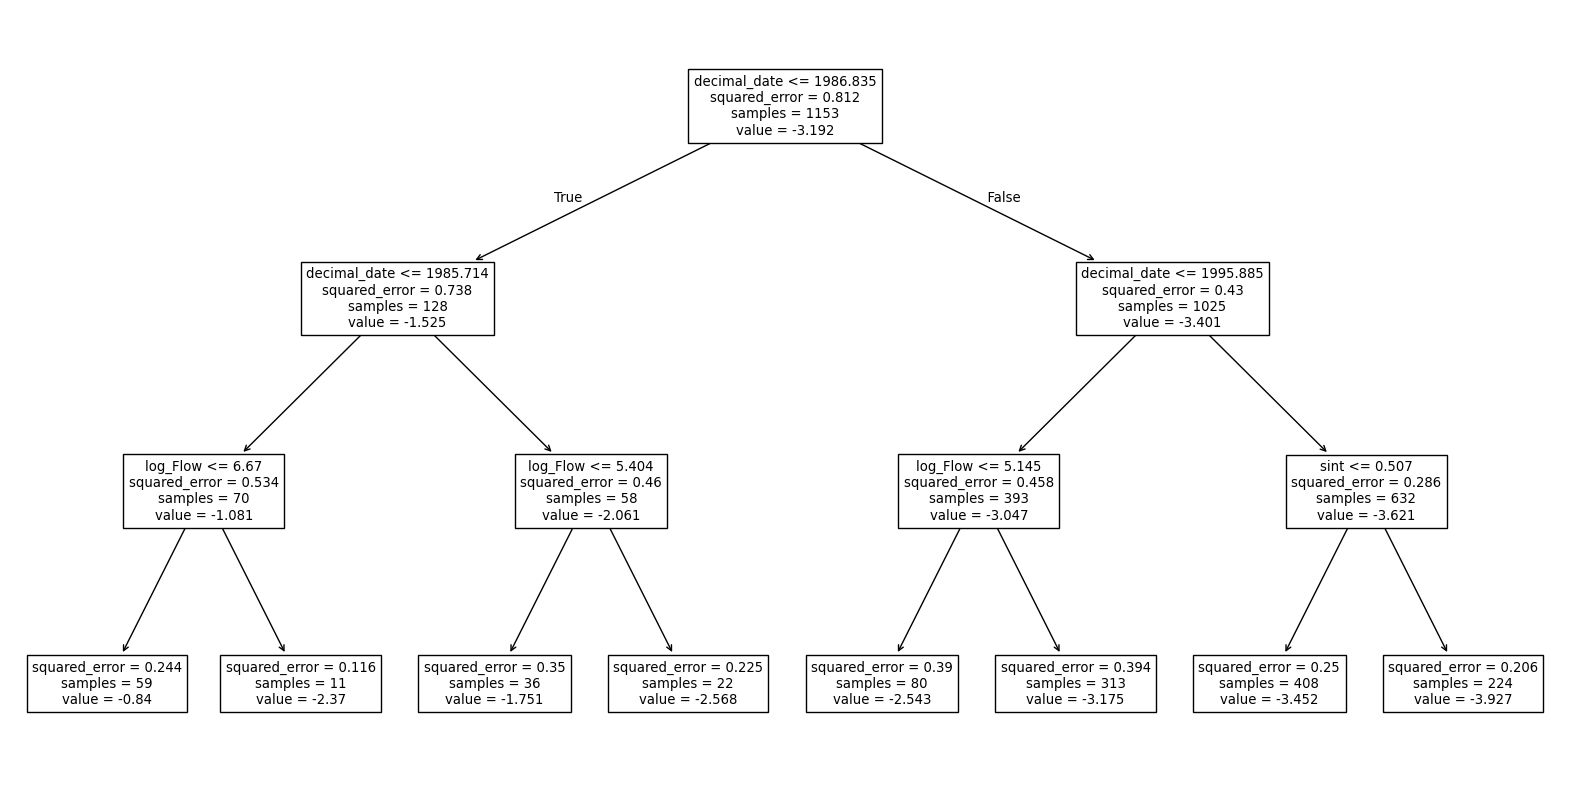

In [143]:
# Fit Regresssion Tree Model
from sklearn.tree import DecisionTreeRegressor
X_tree = Patuxent[['decimal_date', 'log_Flow', 'cost', 'sint']]
y_tree = Patuxent['log_TP']
tree_model = DecisionTreeRegressor(max_depth=3, random_state = 1)
tree_model.fit(X_tree, y_tree)

# Visualize the regression tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X_tree.columns)

A similarity between the regression tree and the local linear model is that both approaches show time (decimal_date) as an important predictor. In both models, earlier years tend to have higher TP values and later years lower ones, so both methods identify a long-term decline in TP.

A key difference is that the tree highlights threshold behavior, such as clear splits in log_flow or seasonal terms, which is harder to see in the smooth local linear model. The local linear model, on the other hand, makes it much easier to see how the effect of flow changes gradually over time, something the tree cannot show because it uses abrupt splits rather than smooth changes.

9. **(1 pt)** Fit the following six models to predict log-TP, using the specified configurations:



- 1: A regression tree with a maximum depth of 3 (same as the model in problem #8).

- 2: A regression tree with a maximum depth of 15.

- 3: A bagging model using 100 regression trees, each with a maximum depth of 3.

- 4: A bagging model using 100 regression trees, each with a maximum depth of 15.

- 5: A boosting model using 100 regression trees, each with a maximum depth of 3.

- 6: A boosting model using 100 regression trees, each with a maximum depth of 15.

    **In a 3X2 panel figure, create a scatter plot of the observed versus fitted values of log-TP for each of the six models above. Be sure to label all axes and title figures so they are easily interpretable.**  
    
    **Finally, use cross validation to calculate and report the 10-fold cross-validated mean squared error for each of the six models. Answer the following questions (*hint: think about what kinds of models work well with bagging vs. boosting in terms of bias and variance*):**

    - **Compare the two bagging models with different tree depths, which peforms better under cross validation, and why do you think this is?**

    - **Compare the two boosting models with different tree depths, which peforms better under cross validation, and why do you think this is?**

    - **Which model performs best overall under cross validation? Is this reflected in the scatter plots for these models? Why or why not?**

In [ ]:
# Fit 6 Models
# Fit same model as in problem 8
tree_model_3 = DecisionTreeRegressor(max_depth=3, random_state = 1)
tree_model_3.fit(X_tree, y_tree)

# Fit regression tree with max depth of 15
tree_model_15 = DecisionTreeRegressor(max_depth=15, random_state = 1)
tree_model_15.fit(X_tree, y_tree)

# Fit Bagging model of 100 tree model 3 trees
from sklearn.ensemble import BaggingRegressor
bagging_model_3 = BaggingRegressor(estimator = tree_model_3, n_estimators=100, random_state=1)
bagging_model_3.fit(X_tree, y_tree)

# Fit Bagging model of 100 tree model 15 trees
bagging_model_15 = BaggingRegressor(estimator = tree_model_15, n_estimators=100, random_state=1)
bagging_model_15.fit(X_tree, y_tree)

# Fit Boosting model of 100 tree model 3 trees
from sklearn.ensemble import AdaBoostRegressor
boosting_model_3 = AdaBoostRegressor(estimator = tree_model_3, n_estimators=100, random_state=1)
boosting_model_3.fit(X_tree, y_tree)

# Fit Boosting model of 100 tree model 15 trees
boosting_model_15 = AdaBoostRegressor(estimator =tree_model_15, n_estimators=100, random_state=1)
boosting_model_15.fit(X_tree, y_tree)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=15, random_state=1),
                  n_estimators=100, random_state=1)

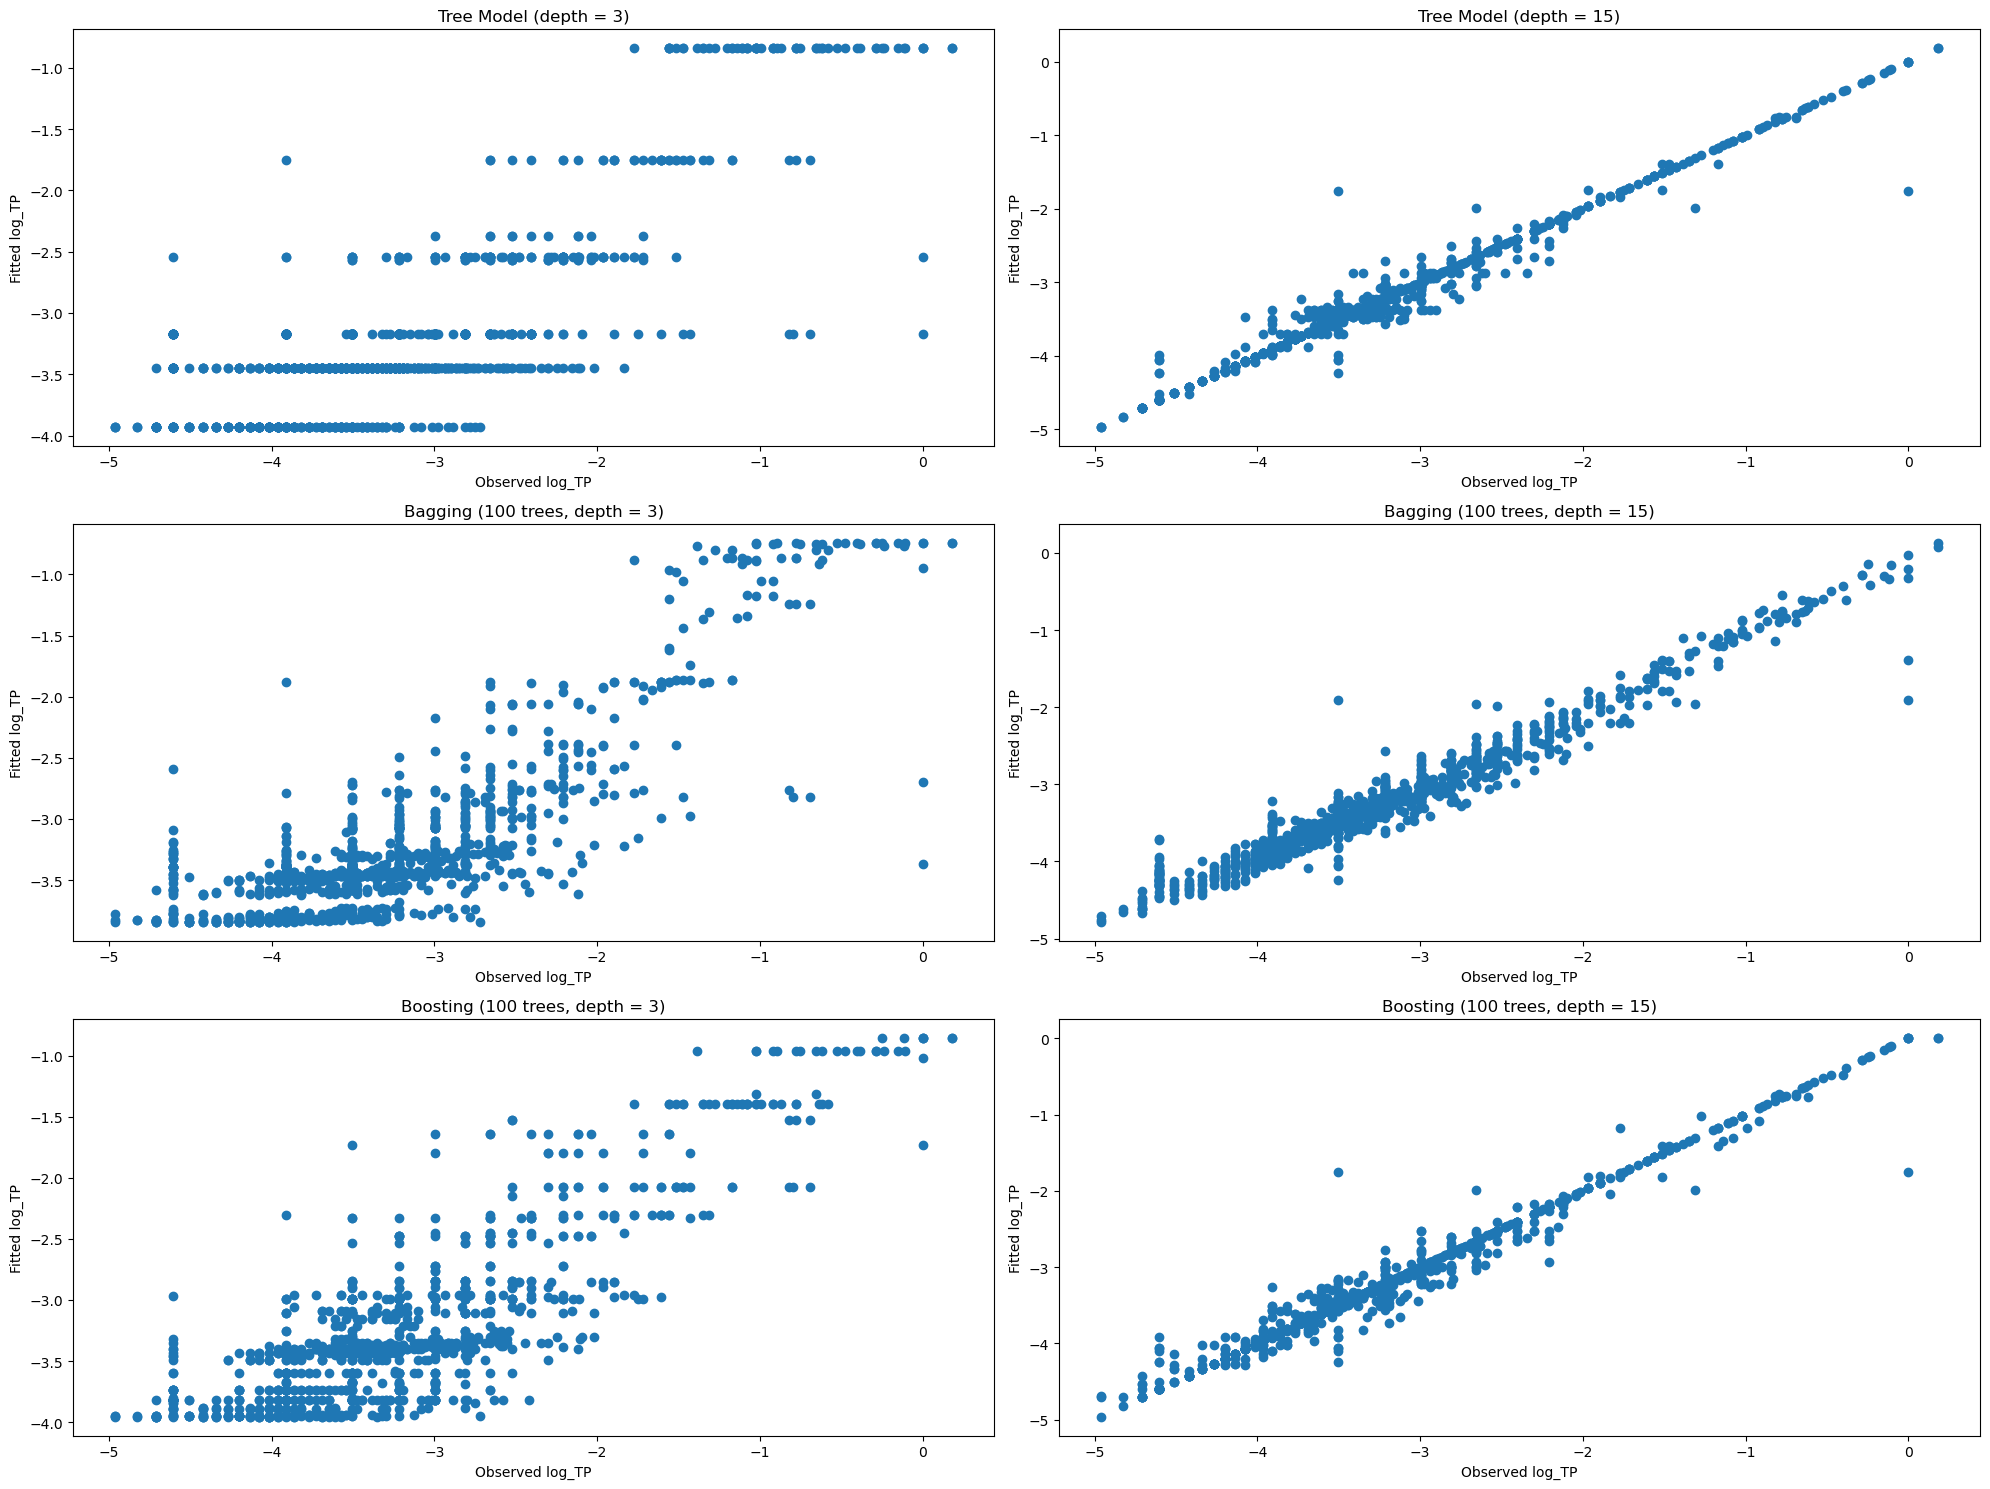

In [ ]:
# Visualize Model Predictions
plt.figure(figsize=(20, 15))

# 1. Tree depth 3
plt.subplot(3, 2, 1)
plt.scatter(y_tree, tree_model_3.predict(X_tree))
plt.xlabel("Observed log_TP")
plt.ylabel("Fitted log_TP")
plt.title("Tree Model (depth = 3)")

# 2. Tree depth 15
plt.subplot(3, 2, 2)
plt.scatter(y_tree, tree_model_15.predict(X_tree))
plt.xlabel("Observed log_TP")
plt.ylabel("Fitted log_TP")
plt.title("Tree Model (depth = 15)")

# 3. Bagging depth 3
plt.subplot(3, 2, 3)
plt.scatter(y_tree, bagging_model_3.predict(X_tree))
plt.xlabel("Observed log_TP")
plt.ylabel("Fitted log_TP")
plt.title("Bagging (100 trees, depth = 3)")

# 4. Bagging depth 15
plt.subplot(3, 2, 4)
plt.scatter(y_tree, bagging_model_15.predict(X_tree))
plt.xlabel("Observed log_TP")
plt.ylabel("Fitted log_TP")
plt.title("Bagging (100 trees, depth = 15)")

# 5. Boosting depth 3
plt.subplot(3, 2, 5)
plt.scatter(y_tree, boosting_model_3.predict(X_tree))
plt.xlabel("Observed log_TP")
plt.ylabel("Fitted log_TP")
plt.title("Boosting (100 trees, depth = 3)")

# 6. Boosting depth 15
plt.subplot(3, 2, 6)
plt.scatter(y_tree, boosting_model_15.predict(X_tree))
plt.xlabel("Observed log_TP")
plt.ylabel("Fitted log_TP")
plt.title("Boosting (100 trees, depth = 15)")

plt.tight_layout()
plt.show()

In [ ]:
# Report the 10-fold CV RMSE for each model
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

def cv_mse(model):
    scores = cross_val_score(model, X_tree, y_tree,
                             scoring="neg_mean_squared_error",
                             cv=10)
    return -scores.mean()

# Compute CV MSEs
mse_tree_3       = cv_mse(tree_model_3)
mse_tree_15      = cv_mse(tree_model_15)
mse_bag_3        = cv_mse(bagging_model_3)
mse_bag_15       = cv_mse(bagging_model_15)
mse_boost_3      = cv_mse(boosting_model_3)
mse_boost_15     = cv_mse(boosting_model_15)

# Print nicely
print("10-fold Cross-Validated MSEs:")
print("Tree (depth 3):              ", mse_tree_3)
print("Tree (depth 15):             ", mse_tree_15)
print("Bagging (100, depth 3):      ", mse_bag_3)
print("Bagging (100, depth 15):     ", mse_bag_15)
print("Boosting (100, depth 3):     ", mse_boost_3)
print("Boosting (100, depth 15):    ", mse_boost_15)

10-fold Cross-Validated MSEs:
Tree (depth 3):               0.5030415292100164
Tree (depth 15):              0.5967826584124263
Bagging (100, depth 3):       0.4829425276087971
Bagging (100, depth 15):      0.4359174532120325
Boosting (100, depth 3):      0.536716608927758
Boosting (100, depth 15):     0.4646359935206833


The bagging model with deeper trees performs better, because bagging reduces variance, so it benefits more from using high-variance base learners like depth-15 trees. For boosting, the deeper trees also perform better, since boosting mainly reduces bias and deeper trees start with lower bias and can learn more complex patterns. Overall, the best model under cross-validation is the bagging model with depth 15, which has the lowest MSE. The scatterplots may not show dramatic differences among models, but the best model should generally have points that fall closer to the 1:1 line, even if the visual improvement is subtle.

10. **(1 pt)**  In this question and the next, we are going to shift gears and revisit the ebird dataset from Assignment 4. Follow the instructions from Assignment 4 to re-create the dataframe called 'ebird_habitat'. This will include steps 1-2 in Assignment 4. Please also review the description of these data from the previous assignment.

    We are going to develop a random forest (RF) model to predict whether or not wood thrushes are present or absent at a given location (i.e., the variable species_observed). We will use the following predictors, which are the same for the logistic regression from problem 3 of Assignment 4:
    - day_of_year
    - time_observations_started
    - duration_minutes
    - effort_distance_km
    - number_observers
    - elevation_median
    - elevation_sd
    - all land cover columns except pland_water
    
    To develop the RF model, follow these steps: 
    - Split the data into training and testing sets, using 30% of the data for testing. Be sure to stratify the training and testing sets based on the presence/absence of wood thrush. 
    - Use GridSearchCV from sklearn.model_selection to estimate the best hyperparameters of the RF model via 3-fold cross-validation, based on maximizing the F1-score. Consider the following hyperpameter values in the grid search:
        - n_estimators: 100, 200, and 300
        - max_depth: 4, 16, 32, and 64
        - max_features: log2 and sqrt
    - Extract the best RF model from the output of GridSearchCV, and use this model to predict the classifications of wood thrush presence/absence on the test set.
    - Note: Look into the documentation of GridSearchCV and refer to the Data Camp assignment on tree-based models for more guidance on these steps. 
    
    **Calculate and report the accuracy of the class predictions from the optimal RF model. Also calculate and report a confusion matrix for the class predictions.**

    **Next, calculate and report the accuracy of class predictions from a logistic regression model fit and evaluated on the same predictors and training and testing data as the RF model above. Also report the confusion matrix for the class predictions.**
    - For this logistic regression, use the same threshold for classification you selected in problem #6 of Assignment 4, based on the optimal F1-score. 

    **Report your conclusion about which model is a better classifier for wood thrush presence/abscence. Justify your answer.**

In [146]:
# Recreate 'ebird_habitat' DataFrame from Assignment 4
ebird = pd.DataFrame(pd.read_csv('ebd_woothr_june_bcr27_zf_copy.csv'))
habitat = pd.DataFrame(pd.read_csv('pland_elev_location_year_copy.csv'))
ebird_habitat = pd.merge(ebird, habitat, on=['year', 'locality_id'], how='inner')
ebird_habitat = ebird_habitat.dropna()
ebird_habitat['species_observed'] = ebird_habitat['species_observed'].astype(int)

In [148]:
from sklearn.model_selection import train_test_split
X = ebird_habitat[['day_of_year', 'time_observations_started', 'duration_minutes', 'effort_distance_km', 'number_observers', 'elevation_median', 'elevation_sd', 'pland_forest', 'pland_grassland_shrubland_savanna', 'pland_wetland', 'pland_cropland', 'pland_urban', 'pland_other']]
y = ebird_habitat['species_observed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# define hyperparameter grid
params = {'n_estimators': [100, 200, 300],
          'max_depth': [4, 16, 32, 64],
          'max_features': ['log2', 'sqrt']}

# Instantiate a 3-fold CV grid search
grid = GridSearchCV(estimator=RandomForestRegressor(random_state=1), param_grid=params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

# Best hyperparameters
best_params = grid.best_params_
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'max_depth': 32, 'max_features': 'log2', 'n_estimators': 300}


In [157]:
# Extract best CV score
best_CV_score = grid.best_score_
print("Best CV Score:", best_CV_score)

#Extract best model
best_model = grid.best_estimator_

#Evaluate best model on test set
test_acc = best_model.score(X_test, y_test)
print("Test Set R^2:", test_acc)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = best_model.predict(X_test)
confusionmatrix = confusion_matrix(y_test, np.round(y_pred))
print("Confusion Matrix:\n", confusionmatrix)

Best CV Score: -0.033433099925687916
Test Set R^2: 0.21310894770090416
Confusion Matrix:
 [[9239   27]
 [ 345   68]]


In [156]:
from sklearn.linear_model import LogisticRegression
# From problem 6, Assignment 4
best_threshold = 0.10

# Fit logistic regression on the training data
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict probabilities on the test set
log_probs = log_model.predict_proba(X_test)[:, 1]

# Convert probabilities to classes using SAME threshold = 0.10
log_class = np.where(log_probs >= best_threshold, 1, 0)

# Accuracy
log_acc = accuracy_score(y_test, log_class)
print("Logistic Regression Accuracy:", log_acc)

# Confusion matrix
log_cm = confusion_matrix(y_test, log_class)
print("Logistic Regression Confusion Matrix:\n", log_cm)

Logistic Regression Accuracy: 0.8873850604401281
Logistic Regression Confusion Matrix:
 [[8445  821]
 [ 269  144]]


The Random Forest model is the better classifier for wood thrush presence/absence. Even though both models achieve relatively high accuracy, the Random Forest confusion matrix shows far fewer false negatives than logistic regression. This means the RF model is more effective at correctly identifying actual wood thrush presence, which is usually the more important class in ecological monitoring. Logistic regression performs reasonably well but misses more true presences due to its linear decision boundary, while the RF model captures nonlinear relationships in the data and therefore classifies presence more reliably.

11. **(1 pt)** Refit a RF model to the ebird_habitat data, but this time using all of the data (not split into training and testing sets). Use the optimal hyperparameters you found in problem #10 above. 

    **Using this fitted model, extract and create a bar plot of the variable importance for all predictors. Be sure to sort the variable importance values before plotting, and label the bars with the predictor names.** 
    
    **Also, report the regression table for the logistic regression from problem 10 above, but again re-fit to the full ebird_habitat dataset.**

    **Comment on one similarity and one difference between the predictors emphasized by the two approaches.** 

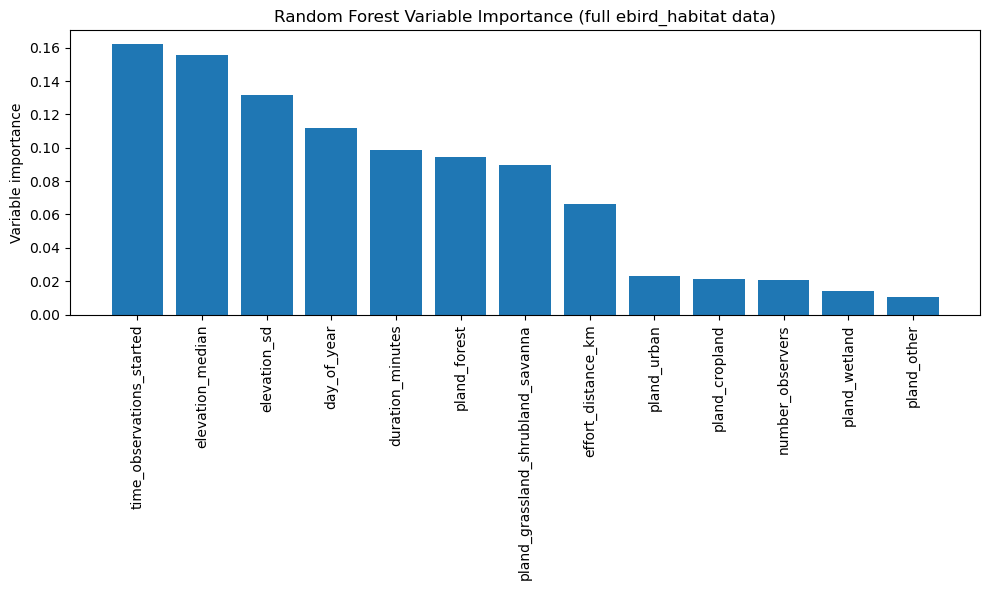

In [158]:
# Instantiate RF model with best hyperparameters
RF = RandomForestRegressor(max_depth=32, max_features='log2', n_estimators=300, random_state=1)
RF.fit(X,y)

# Get importances and names
importances = RF.feature_importances_
feature_names = X.columns.values

# Sort from most to least important
idx = np.argsort(importances)[::-1]
sorted_importances = importances[idx]
sorted_names = feature_names[idx]

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importances)), sorted_importances)
plt.xticks(range(len(sorted_importances)), sorted_names, rotation=90)
plt.ylabel("Variable importance")
plt.title("Random Forest Variable Importance (full ebird_habitat data)")
plt.tight_layout()
plt.show()

In [159]:
# Add intercept
X_full = sm.add_constant(X)

# Fit logistic regression on full data
logit_full = sm.Logit(y, X_full).fit()

# Regression table
print(logit_full.summary())

Optimization terminated successfully.
         Current function value: 0.152925
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:       species_observed   No. Observations:                48391
Model:                          Logit   Df Residuals:                    48377
Method:                           MLE   Df Model:                           13
Date:                Sat, 29 Nov 2025   Pseudo R-squ.:                  0.1385
Time:                        14:15:44   Log-Likelihood:                -7400.2
converged:                       True   LL-Null:                       -8589.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -1.6604      0.547     -

Similarity:
Both the Random Forest and the logistic regression model identify elevation_median as an important predictor.
In the RF, elevation_median is one of the highest variable-importance scores, and in the logistic regression it has a highly significant positive coefficient (p < 0.001). This suggests that higher elevation consistently increases the probability of detecting a wood thrush in both modeling approaches.

Difference:
A major difference is that the Random Forest places strong emphasis on time_observations_started (it is the most important predictor), while the logistic regression gives this variable a negative but relatively small linear coefficient.
The RF can capture nonlinear and interaction effects in observation start time, which likely explains why it ranks so high, but the logistic model can only fit a simple linear trend and therefore shows a weaker effect.
Another noticeable difference is that the logistic regression gives a very large positive coefficient to pland_forest, while in the RF model, pland_forest is important but not nearly as dominant. This reflects that logistic regression focuses on strong linear relationships, while the RF spreads importance across multiple interacting habitat variables.

I used ChatGPT (OpenAI, 2025) in support of my solutions to problems 10, 11 on this assignment.
OpenAI. (2025). ChatGPT (August 28 version) [Large language model]. https://chat.openai.com

GitHub Copilot was active for the whole assignment.